# RBIG Demo
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/04_rbig_demo.ipynb)

This notebook demonstrates the full RBIG workflow using `AnnealedRBIG`:

1. Fit the model to data
2. Transform data to Gaussian space
3. Invert the transform (check for accuracy)
4. Sample new data from the learned distribution
5. Estimate log-probabilities

For the full theory behind RBIG, see the [RBIG Walk-Through](./03_rbig_walkthrough.ipynb).

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [1]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
from time import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from rbig import AnnealedRBIG

sns.set_style("whitegrid")

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Toy Data

A 2-D "sin-wave" distribution: $x \sim |2\mathcal{N}(0,1)|$,
$y = \sin(x) + 0.25\,\varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$.

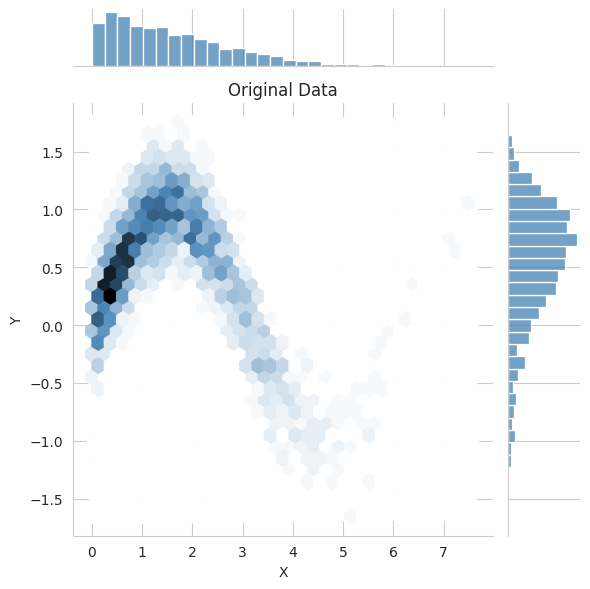

In [3]:
seed = 123
rng = np.random.RandomState(seed=seed)

num_samples = 2_000
x = np.abs(2 * rng.randn(1, num_samples))
y = np.sin(x) + 0.25 * rng.randn(1, num_samples)
data = np.vstack((x, y)).T

g = sns.jointplot(x=data[:, 0], y=data[:, 1], kind="hex", color="steelblue")
g.ax_joint.set_xlabel("X")
g.ax_joint.set_ylabel("Y")
g.ax_joint.set_title("Original Data")
plt.tight_layout()
plt.show()

## RBIG Fitting

In [4]:
n_layers = 50
rotation_type = "pca"
random_state = 123
patience = 10

t0 = time()
rbig_model = AnnealedRBIG(
    n_layers=n_layers,
    rotation=rotation_type,
    random_state=random_state,
    patience=patience,
)
rbig_model.fit(data)
print(f"Fitted {len(rbig_model.layers_)} layers in {time() - t0:.2f}s")

Fitted 27 layers in 5.69s


### Transform Data into Gaussian Space

Transformed data shape: (2000, 2)


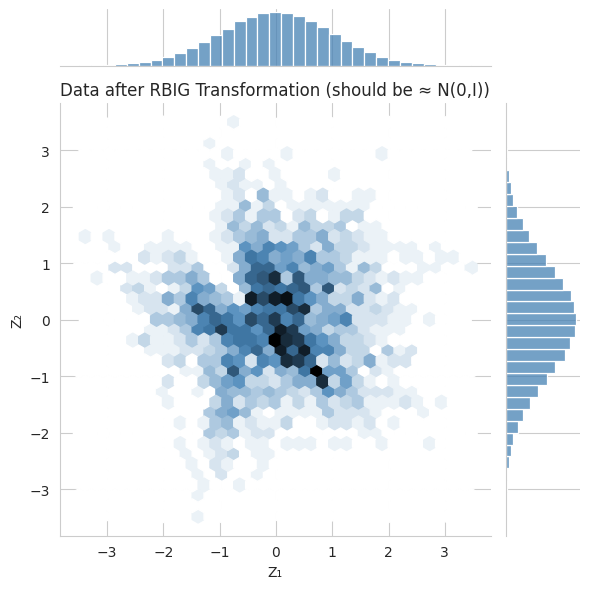

In [5]:
data_trans = rbig_model.transform(data)

print(f"Transformed data shape: {data_trans.shape}")
g = sns.jointplot(x=data_trans[:, 0], y=data_trans[:, 1], kind="hex", color="steelblue")
g.ax_joint.set_xlabel("Z₁")
g.ax_joint.set_ylabel("Z₂")
g.ax_joint.set_title("Data after RBIG Transformation (should be ≈ N(0,I))")
plt.tight_layout()
plt.show()

### Invertible Transform

RBIG is a diffeomorphism — the transform is exactly invertible (up to
numerical precision).

In [6]:
t0 = time()
data_approx = rbig_model.inverse_transform(data_trans)
print(f"Inverse transform in {time() - t0:.2f}s")

abs_diff = np.abs(data - data_approx)
max_err = abs_diff.max()
mean_err = abs_diff.mean()
residual = abs_diff.sum()
print(
    f"Reconstruction error — max: {max_err:.2e}, "
    f"mean: {mean_err:.2e}, sum: {residual:.2e}"
)
tol = 1e-4
if max_err > tol:
    print(
        f"Warning: maximum reconstruction error {max_err:.2e} "
        f"exceeds tolerance {tol:.1e}"
    )

Inverse transform in 0.03s
Reconstruction error — max: 4.87e+00, mean: 2.53e-02, sum: 1.01e+02


### Information Reduction per Layer

`tc_per_layer_` records the total correlation (TC) of the transformed data
after each layer.  As the algorithm converges, TC drops to (near) zero.

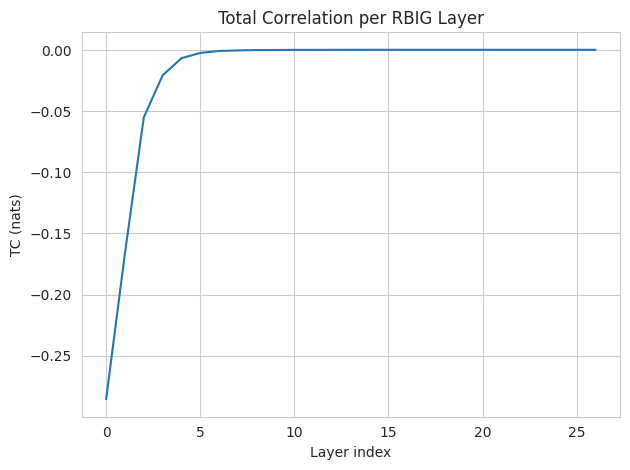

In [7]:
fig, ax = plt.subplots()
ax.plot(rbig_model.tc_per_layer_)
ax.set_xlabel("Layer index")
ax.set_ylabel("TC (nats)")
ax.set_title("Total Correlation per RBIG Layer")
plt.tight_layout()
plt.show()

### Synthesize New Data from the RBIG Model

Because RBIG is invertible we can generate new samples by:
1. Sampling from the standard Gaussian (the latent space).
2. Applying the inverse transform.

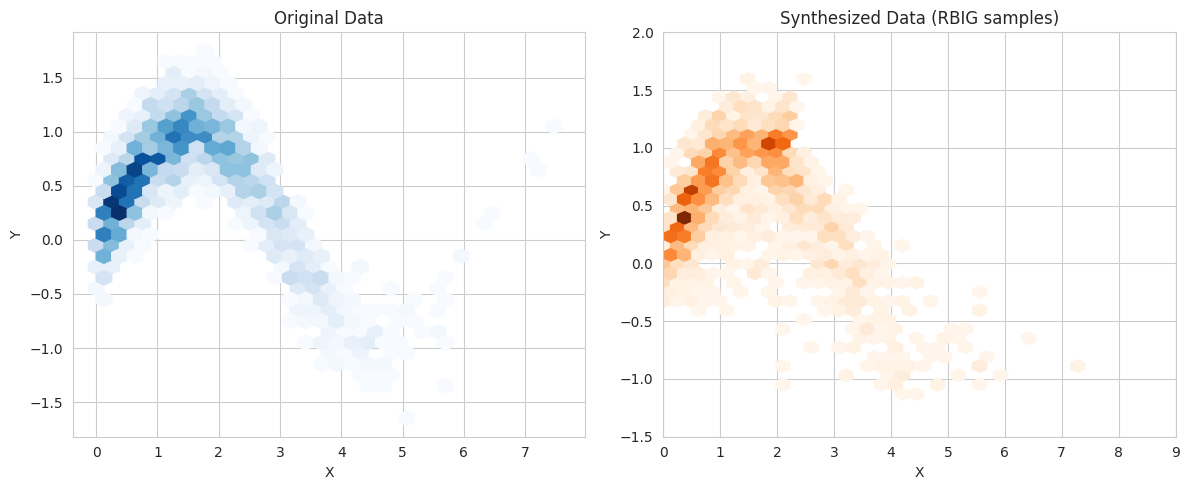

In [8]:
# Step 1 — sample from the fitted Gaussian latent space
data_synthetic_latent = rng.randn(num_samples, data.shape[1])

# Step 2 — map back to data space via inverse transform
data_synthetic = rbig_model.inverse_transform(data_synthetic_latent)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hexbin(data[:, 0], data[:, 1], gridsize=30, cmap="Blues", mincnt=1)
axes[0].set_title("Original Data")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

axes[1].hexbin(
    data_synthetic[:, 0], data_synthetic[:, 1], gridsize=30, cmap="Oranges", mincnt=1
)
axes[1].set_title("Synthesized Data (RBIG samples)")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_ylim([-1.5, 2.0])
axes[1].set_xlim([0.0, 9.0])

plt.tight_layout()
plt.show()

Alternatively, use the built-in `sample()` method:

In [9]:
data_sampled = rbig_model.sample(n_samples=1000, random_state=42)
print(f"Sampled data shape: {data_sampled.shape}")

Sampled data shape: (1000, 2)


## Estimating Log-Probabilities with RBIG

`score_samples(X)` returns the log-likelihood of each sample under the RBIG
model using the change-of-variables formula:

$$\log p(x) = \log p_Z(f(x)) + \log|\det J_f(x)|$$

See the [RBIG algorithm note](../notes/rbig.md) for the change-of-variables derivation.

In [10]:
t0 = time()
log_probs = rbig_model.score_samples(data)
print(f"score_samples in {time() - t0:.2f}s")
print(f"Log-prob — min: {log_probs.min():.3f}, max: {log_probs.max():.3f}")

score_samples in 0.08s
Log-prob — min: -8.082, max: 117.894


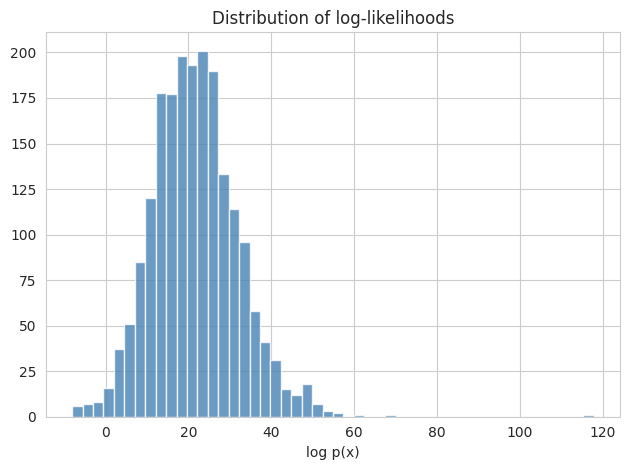

In [11]:
fig, ax = plt.subplots()
ax.hist(log_probs, bins=50, color="steelblue", alpha=0.8)
ax.set_xlabel("log p(x)")
ax.set_title("Distribution of log-likelihoods")
plt.tight_layout()
plt.show()

### Visualise log-probabilities on the original data

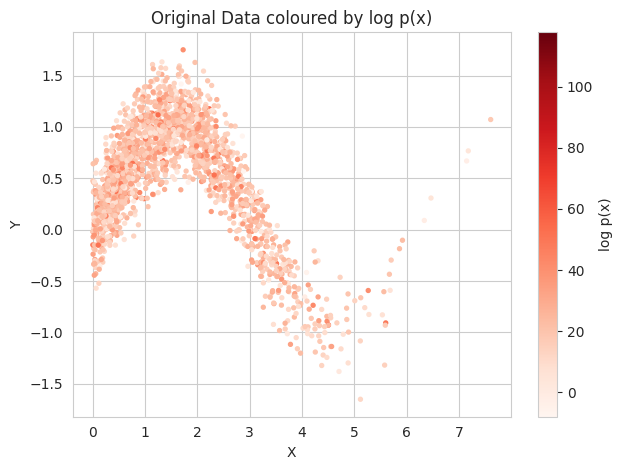

In [12]:
fig, ax = plt.subplots()
h = ax.scatter(data[:, 0], data[:, 1], s=8, c=log_probs, cmap="Reds")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Original Data coloured by log p(x)")
plt.colorbar(h, ax=ax, label="log p(x)")
plt.tight_layout()
plt.show()

## Benchmarks — Larger Dataset

The following cells benchmark `AnnealedRBIG` on a moderately large dataset
(2 000 samples, 10 features).

In [13]:
data_bench = rng.randn(2_000, 10)

t0 = time()
rbig_bench = AnnealedRBIG(
    n_layers=30,
    rotation="pca",
    patience=10,
    random_state=0,
)
rbig_bench.fit(data_bench)
print(
    f"Benchmark: {len(rbig_bench.layers_)} layers, "
    f"{data_bench.shape[0]} samples x {data_bench.shape[1]} features "
    f"in {time() - t0:.2f}s"
)

Benchmark: 30 layers, 2000 samples x 10 features in 31.86s


## Summary

| Method | Description |
|---|---|
| `AnnealedRBIG.fit(X)` | Iteratively fit RBIG layers until TC convergence |
| `.transform(X)` | Map data to Gaussian latent space |
| `.inverse_transform(Z)` | Map latent samples back to data space |
| `.sample(n, random_state)` | Draw new samples from the learned distribution |
| `.score_samples(X)` | Per-sample log-likelihood via change-of-variables |
| `.score(X)` | Mean log-likelihood |
| `.entropy()` | Entropy of the fitted distribution (in nats) |

---
## See Also

- [RBIG Algorithm Note](../notes/rbig.md) — theory and derivation of the RBIG algorithm
- [RBIG Walk-Through](./03_rbig_walkthrough.ipynb) — step-by-step walkthrough of RBIG internals
- [Configuration](../notes/configuration.md) — guide to configuring RBIG parameters